In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [44]:
df=pd.read_excel('BlinkIT Grocery Data (1).xlsx')
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


# Data Understanding

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [46]:
df.shape

(8523, 12)

In [58]:
df.isnull().sum()*100/len(df)

Item Fat Content             0.0
Item Identifier              0.0
Item Type                    0.0
Outlet Establishment Year    0.0
Outlet Identifier            0.0
Outlet Location Type         0.0
Outlet Size                  0.0
Outlet Type                  0.0
Item Visibility              0.0
Item Weight                  0.0
Sales                        0.0
Rating                       0.0
dtype: float64

In [48]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

## Data Cleaning

In [49]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [50]:
df['Item Fat Content']= df['Item Fat Content'].replace({
    'low fat':'Low Fat',
    'LF':'Low Fat',
    'reg':'Regular'})

<Axes: xlabel='Item Weight'>

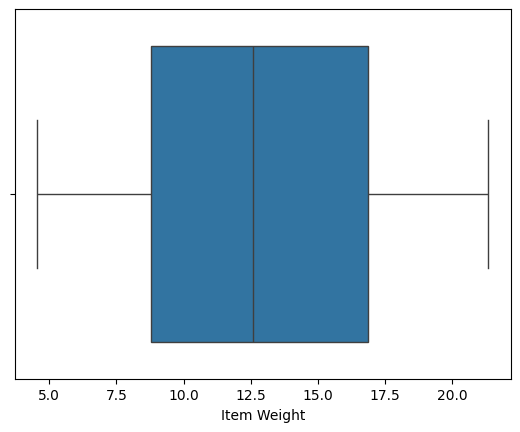

In [52]:
sns.boxplot(x=df['Item Weight'])

In [55]:
df['Item Weight']=df['Item Weight'].fillna(df['Item Weight'].median())

## Data Visualisation

In [118]:
group= df.groupby(df['Item Type'],as_index=False)['Item Visibility'].sum().sort_values(by='Item Visibility',ascending=False)

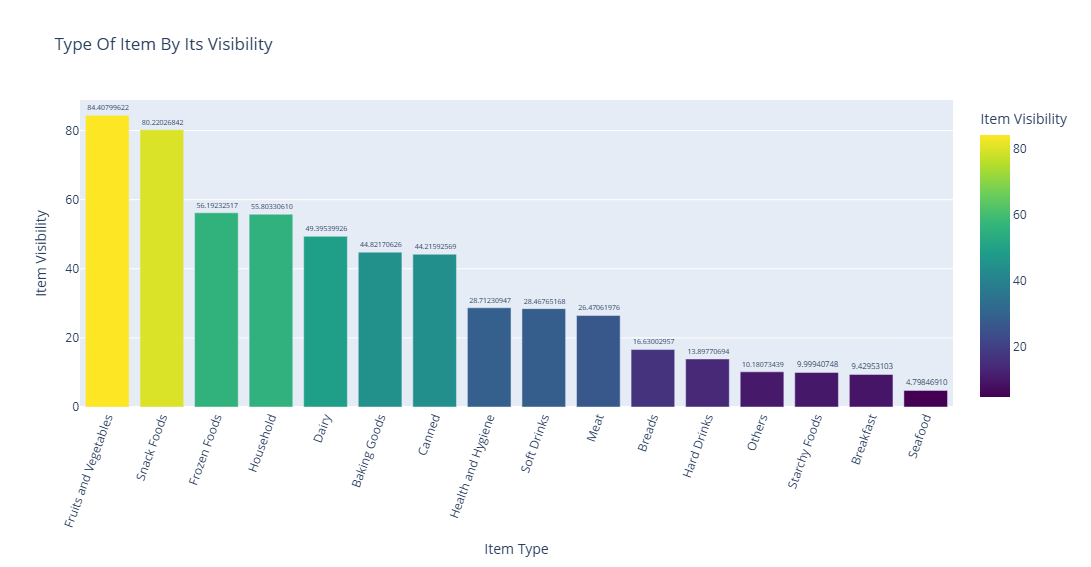

In [117]:
fig= px.bar(group,
            x='Item Type',
            y='Item Visibility',
            title='Type Of Item By Its Visibility',
            text='Item Visibility',
            color='Item Visibility',
            color_continuous_scale=px.colors.sequential.Viridis)
fig.update_traces(
     texttemplate=' %{y:.8f}',
    textposition='outside',
    textfont_size=12)
fig.update_layout(
    width=1600,
    height=550,
    autosize=False,
     xaxis_title='Item Type',
    yaxis_title='Item Visibility',
    xaxis_tickangle=-70,
    xaxis={'categoryorder': 'total descending'}
)
fig.show()

### Fruits And Vegetables have the highest visibility on blinkit of total 84%

In [103]:
group= df.groupby(df['Item Fat Content'],as_index=False)['Sales'].sum().sort_values(by='Sales',ascending=False)

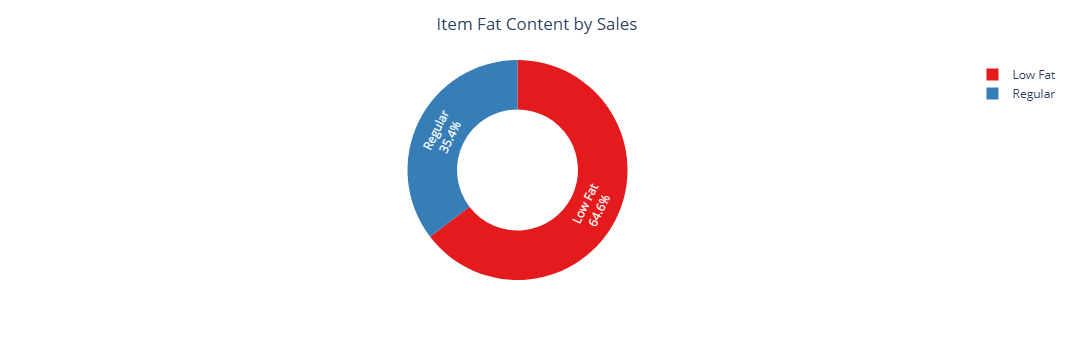

In [104]:
fig= px.pie(
    group,
    names='Item Fat Content',
    values='Sales',
    hole=0.55,
    color_discrete_sequence=px.colors.qualitative.Set1)
fig.update_traces(
    textinfo='percent+label',
)
fig.update_layout(
    title={
        'text':'Item Fat Content by Sales',
        'x': 0.5,
        'xanchor':'center'
    },
    showlegend=True
)
fig.show()

### Low Fat is making more sales than regular fat. 

## Item Type by Sales

In [162]:
group= df.groupby(df['Item Type'],as_index=False)['Sales'].sum().sort_values(by='Sales',ascending=False)

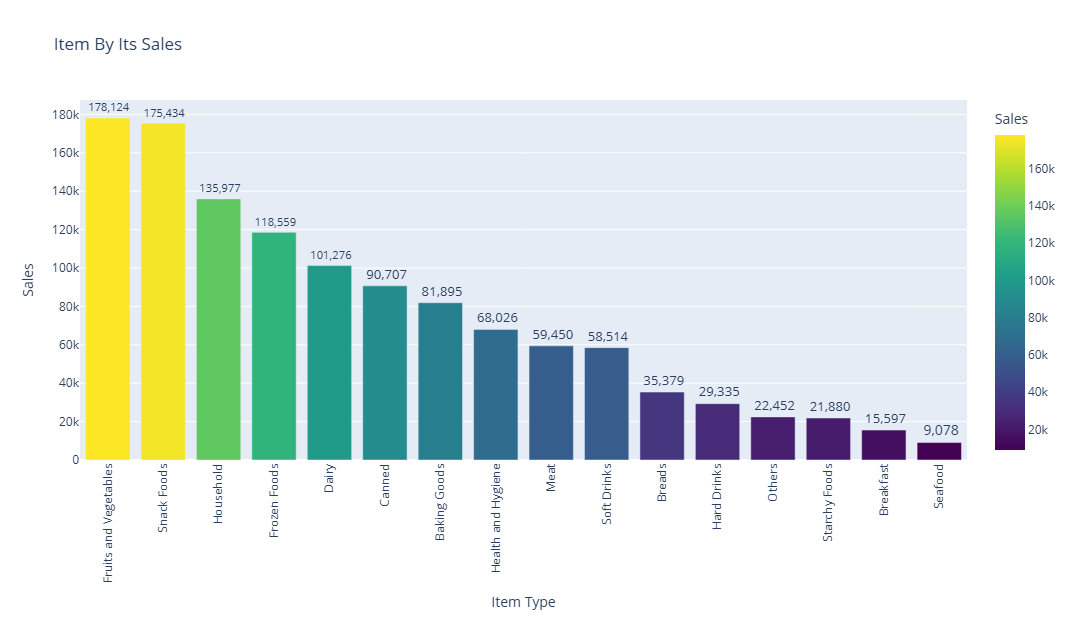

In [132]:
fig=px.bar(
    group,
    x='Item Type',
    y='Sales',
    title='Item By Its Sales',
    text='Sales',
    color='Sales',
     color_continuous_scale=px.colors.sequential.Viridis)
fig.update_traces(
     texttemplate=' %{y:,.0f}',
    textposition='outside',
    textfont_size=14)
fig.update_layout(
    width=1000,
    height=620,
    autosize=False,
    xaxis_tickangle=-90,
    xaxis={'categoryorder': 'total descending'}
)
fig.show()


### Fruits and vegetables have the highest sale of total 178124Rs.

## Item Type by Rating

In [163]:
group= df.groupby(df['Item Type'],as_index=False)['Rating'].sum().sort_values(by='Rating',ascending=False)

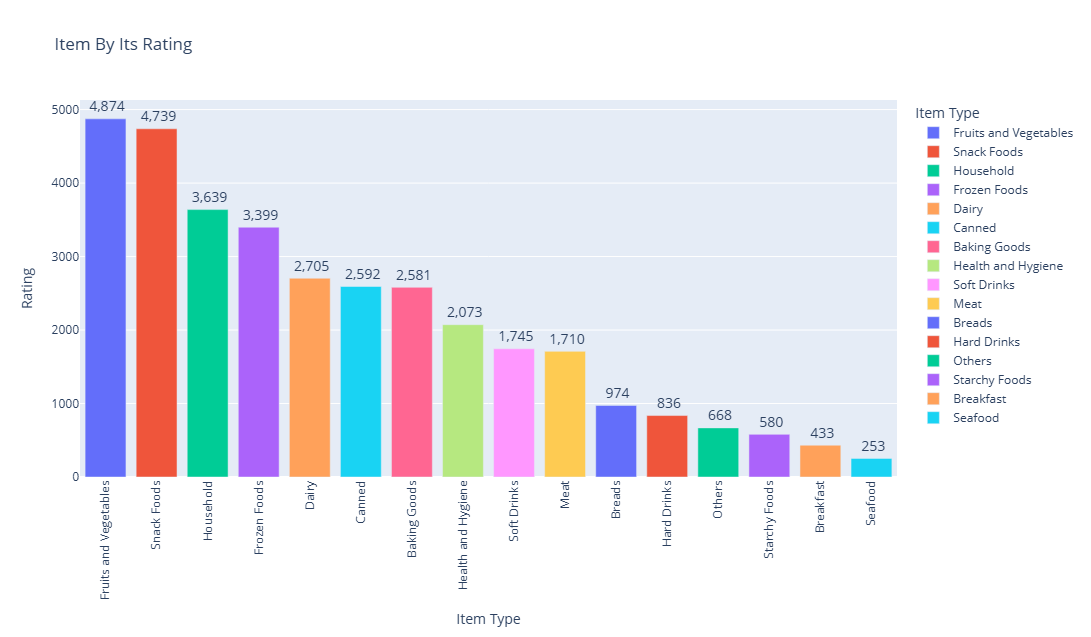

In [164]:
fig=px.bar(
    group,
    x='Item Type',
    y='Rating',
    title='Item By Its Rating',
    text='Item Type',
    color='Item Type',
     color_continuous_scale=px.colors.sequential.Viridis)
fig.update_traces(
     texttemplate=' %{y:,.0f}',
    textposition='outside',
    textfont_size=14)
fig.update_layout(
    width=1400,
    height=620,
    autosize=False,
    xaxis_tickangle=-90,
    xaxis={'categoryorder': 'total descending'}
)
fig.show()


### Fruits & Vegetables have the highest rating consisting of 4874 total ratings

## Item Fat Content by Rating

In [137]:
group= df.groupby(df['Item Fat Content'],as_index=False)['Rating'].sum().sort_values(by='Rating',ascending=False)

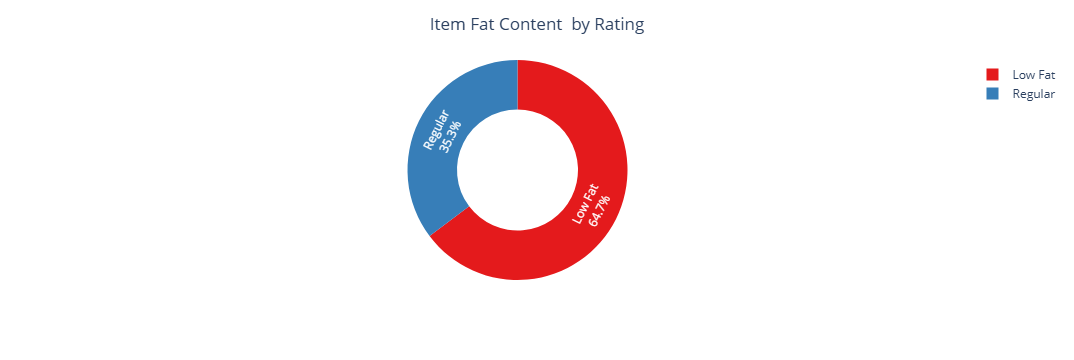

In [138]:
fig = px.pie(
    group,
    names='Item Fat Content',
    values='Rating',
    hole=0.55,   # donut style
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(
    textinfo='percent+label'
 )

fig.update_layout(
    title={
        'text': 'Item Fat Content  by Rating',
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True
)

fig.show()

## Outlet Size by Sales

In [139]:
group= df.groupby(df['Outlet Size'],as_index=False)['Sales'].sum().sort_values(by='Sales',ascending=False)

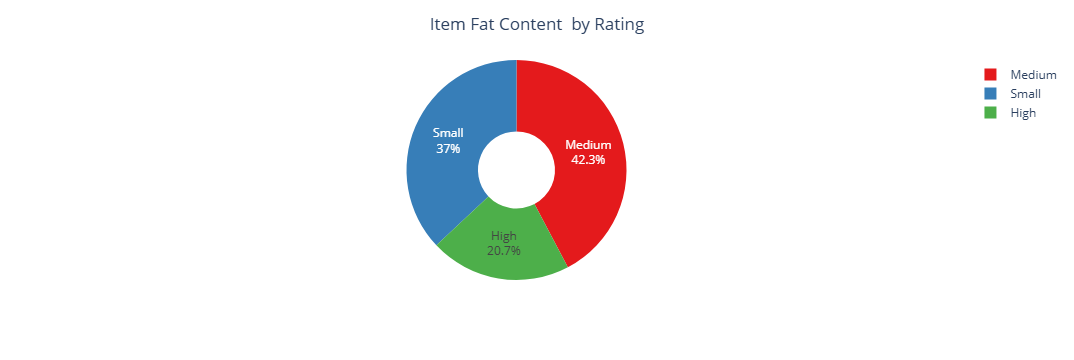

In [142]:
fig = px.pie(
    group,
    names='Outlet Size',
    values='Sales',
    hole=0.35,   # donut style
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(
    textinfo='percent+label'
 )

fig.update_layout(
    title={
        'text': 'Item Fat Content  by Rating',
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True
)

fig.show()


### Medium Size of outlet gets highest rating

## Outlet Establishment Year by Sales

In [166]:
group= df.groupby(df['Outlet Establishment Year'],as_index=False)['Sales'].sum().sort_values(by='Sales',ascending=False)

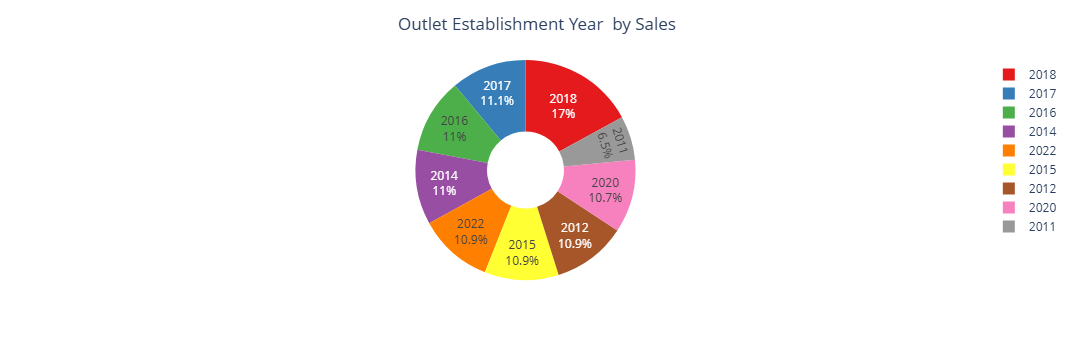

In [167]:
fig = px.pie(
    group,
    names='Outlet Establishment Year',
    values='Sales',
    hole=0.35,   # donut style
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(
    textinfo='percent+label'
 )

fig.update_layout(
    title={
        'text': 'Outlet Establishment Year  by Sales',
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True
)

fig.show()


### Outlet established in 2018 makes the highest sale of 17%

## Outlet Location Type by Sales

In [159]:
group= df.groupby(df['Outlet Location Type'],as_index=False)['Sales'].sum().sort_values(by='Sales',ascending=False)

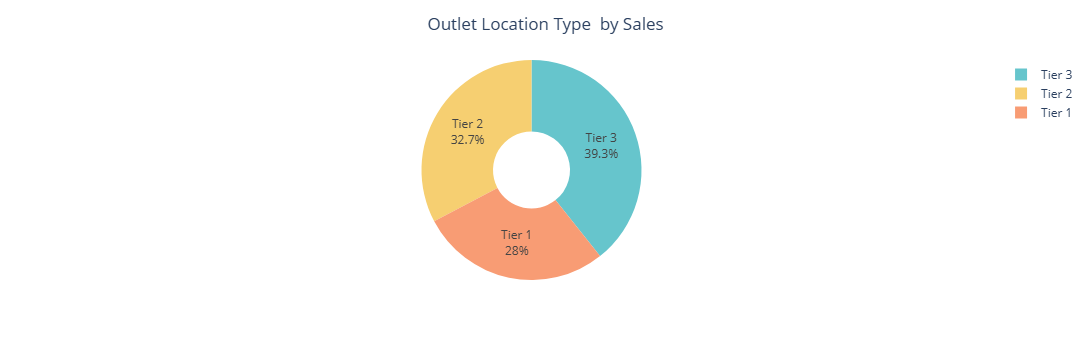

In [160]:
fig = px.pie(
    group,
    names='Outlet Location Type',
    values='Sales',
    hole=0.35,   # donut style
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_traces(
    textinfo='percent+label'
 )

fig.update_layout(
    title={
        'text': 'Outlet Location Type  by Sales',
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True
)

fig.show()

### Tier 3 Outlet makes the highest sale of total 39.3%